# 04 — Compléments théoriques et files Hawkes v4

Ce notebook regroupe deux blocs du projet MODAL Queue Reactive :

- **Section 2.1** : comparaison entre probabilité d'atteindre zéro pour un processus birth-death discret et pour son approximation brownienne ;
- **Section 1.2.4** : simulation de files Hawkes en convention corrigée **v4**.

Dans tout le notebook, les formules inline utilisent `$...$` et les formules affichées utilisent `$$...$$`.

La convention v4 est :

$$
\lambda^-(t)
=\mu^- - \int_0^t \alpha e^{-\beta(t-s)}\,dN_s^+
+ \int_0^t \alpha e^{-\beta(t-s)}\,dN_s^- .
$$

Un ajout diminue temporairement le taux de retrait futur ; un retrait augmente temporairement le taux de retrait futur.


In [1]:
import sys
sys.path.insert(0, '.')

import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from model.hawkes import (
        simulate_hawkes_queue,
        simulate_coupled_hawkes,
        hawkes_stationary_intensity,
        prob_reach_zero_discrete,
        prob_reach_zero_brownian,
        compare_hitting_probabilities,
    )
except ModuleNotFoundError:
    from model.Hawkes import (
        simulate_hawkes_queue,
        simulate_coupled_hawkes,
        hawkes_stationary_intensity,
        prob_reach_zero_discrete,
        prob_reach_zero_brownian,
        compare_hitting_probabilities,
    )

from model.hitting_times import simulate_until_hit_zero, batch_hitting_times

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
MU_PLUS = 1.2
MU_MINUS = 1.5
ALPHA = 0.3
BETA = 0.5
RATIO = ALPHA / BETA
Q0 = 10

COLORS = {
    'hawkes': '#7A3E9D',
    'hawkes2': '#C44E52',
    'poisson': '#2F6B9A',
    'poisson2': '#E08D3C',
    'theory': '#202020',
    'green': '#3F8F5F',
    'gray': '#8A8A8A',
}


def style_axes(ax, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, pad=10, fontweight='semibold')
    ax.grid(True, alpha=0.25, linestyle='--')
    return ax


def add_panel_label(ax, label):
    ax.text(0.015, 0.96, label, transform=ax.transAxes,
            ha='left', va='top', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='0.85', alpha=0.9))


def ci95(arr):
    arr = np.asarray(arr, dtype=float)
    m = arr.mean()
    s = arr.std(ddof=1)
    h = 1.96 * s / np.sqrt(len(arr))
    return m, s, m - h, m + h

print(f"Paramètres : μ⁺={MU_PLUS}, μ⁻={MU_MINUS}, α={ALPHA}, β={BETA}, α/β={RATIO:.2f}")
print("simulate_hawkes_queue :", inspect.signature(simulate_hawkes_queue))
print("simulate_coupled_hawkes :", inspect.signature(simulate_coupled_hawkes))


Paramètres : μ⁺=1.2, μ⁻=1.5, α=0.3, β=0.5, α/β=0.60
simulate_hawkes_queue : (q_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.Hawkes.HawkesQueueResult
simulate_coupled_hawkes : (q1_init: int = 10, q_neg1_init: int = 10, mu_plus: float = 1.2, mu_minus: float = 1.5, alpha: float = 0.3, beta: float = 0.5, T_max: float = 1000.0, rng: Optional[numpy.random._generator.Generator] = None, stop_at_zero: bool = True, sign_convention: str = 'v4') -> model.Hawkes.CoupledHawkesResult


---
# Partie A — Section 2.1 : discret contre brownien

On considère un processus birth-death $X_t$ sur $\mathbb{Z}_+$, partant de $a>0$ :

$$
X_t=a+N_t^+-N_t^- ,
$$

avec $N_t^+$ d'intensité $\lambda^+$ et $N_t^-$ d'intensité $\lambda^-$. La probabilité discrète d'atteindre zéro est :

$$
\mathbb{P}_a(T_0<\infty)=
\begin{cases}
1, & \lambda^-\geq \lambda^+,\\
\rho^a, & \lambda^-<\lambda^+,
\end{cases}
\qquad
\rho=\frac{\lambda^-}{\lambda^+}.
$$

Pour le brownien approché

$$
B_t=a+\mu t+\sigma W_t,
\qquad
\mu=\lambda^+-\lambda^-,
\qquad
\sigma^2=\lambda^+ + \lambda^-,
$$

la probabilité d'atteindre zéro vaut :

$$
\mathbb{P}^{BM}_a(T_0<\infty)=
\begin{cases}
1, & \mu\leq 0,\\
\exp\!\left(-\dfrac{2\mu a}{\sigma^2}\right), & \mu>0.
\end{cases}
$$


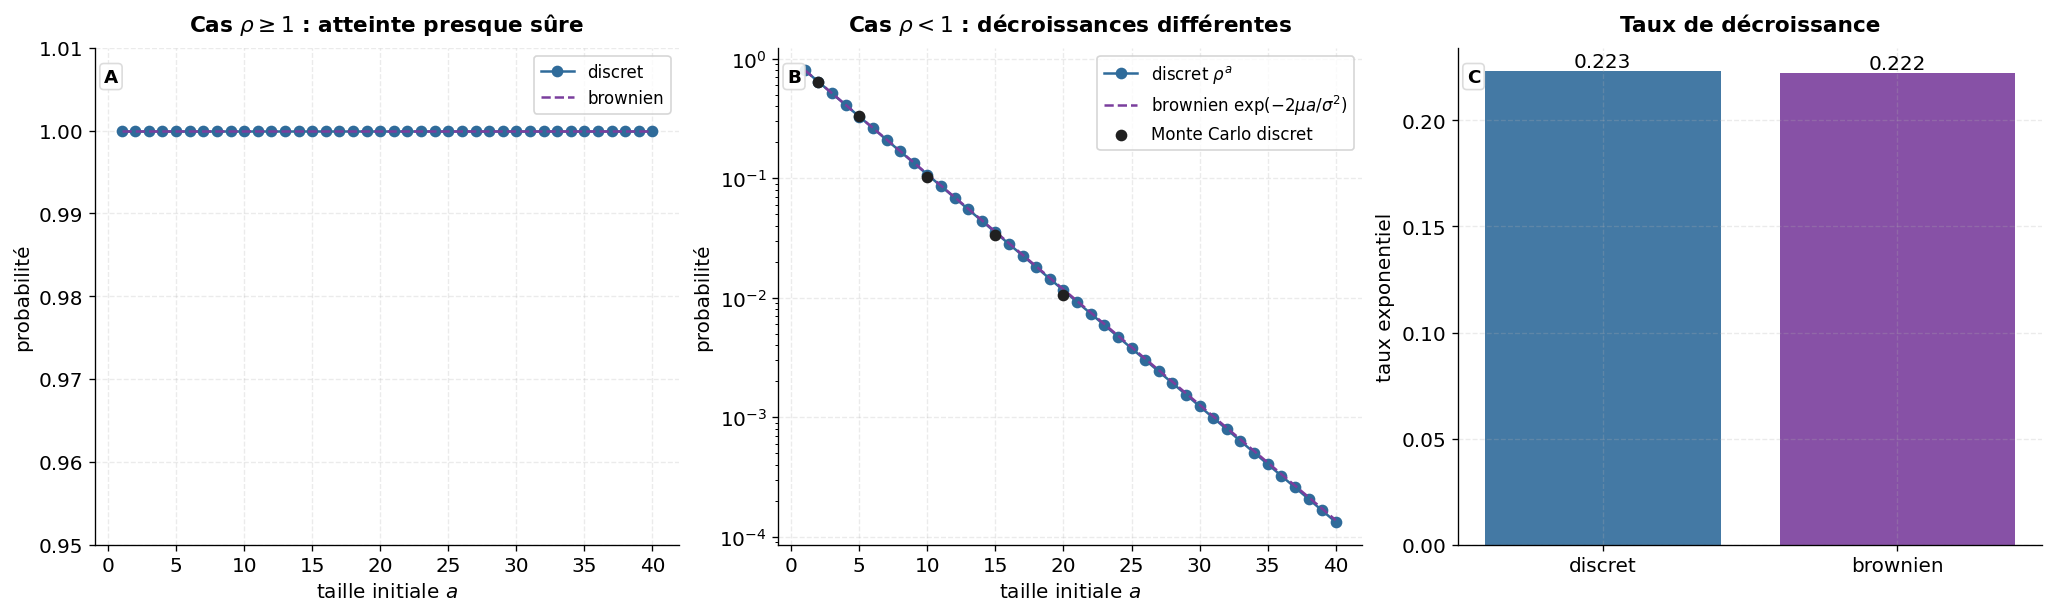

,a,MC discret,formule discrète,formule brownienne
0,2,0.63750,0.640000,0.641180
1,5,0.32915,0.327680,0.329193
2,10,0.10290,0.107374,0.108368
3,15,0.03370,0.035184,0.035674
4,20,0.01050,0.011529,0.011744


In [2]:
def estimation_mc_atteinte_zero(a, lambda_plus, lambda_minus, n_runs=20_000, max_events=20_000, seed=42):
    rng = np.random.default_rng(seed)
    p_add = lambda_plus / (lambda_plus + lambda_minus)
    hits = 0
    for _ in range(n_runs):
        q = int(a)
        for _ in range(max_events):
            q += 1 if rng.random() < p_add else -1
            if q <= 0:
                hits += 1
                break
            if q > 10 * max(a, 1) + 500:
                break
    return hits / n_runs


a_values = np.arange(1, 41)

lp_down, lm_down = 1.2, 1.5
comp_down = compare_hitting_probabilities(a_values, lp_down, lm_down)

lp_up, lm_up = 1.5, 1.2
comp_up = compare_hitting_probabilities(a_values, lp_up, lm_up)

a_mc = np.array([2, 5, 10, 15, 20])
p_mc = np.array([
    estimation_mc_atteinte_zero(a, lp_up, lm_up, n_runs=20_000, seed=SEED + int(a))
    for a in a_mc
])

fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout='constrained')

axes[0].plot(a_values, comp_down['p_discrete'], 'o-', color=COLORS['poisson'], label='discret')
axes[0].plot(a_values, comp_down['p_brownian'], '--', color=COLORS['hawkes'], label='brownien')
axes[0].set_ylim(0.95, 1.01)
style_axes(axes[0], 'taille initiale $a$', 'probabilité', r'Cas $\rho\geq 1$ : atteinte presque sûre')
axes[0].legend(frameon=True)
add_panel_label(axes[0], 'A')

axes[1].semilogy(a_values, comp_up['p_discrete'], 'o-', color=COLORS['poisson'], label=r'discret $\rho^a$')
axes[1].semilogy(a_values, comp_up['p_brownian'], '--', color=COLORS['hawkes'], label=r'brownien $\exp(-2\mu a/\sigma^2)$')
axes[1].scatter(a_mc, p_mc, color=COLORS['theory'], zorder=5, label='Monte Carlo discret')
style_axes(axes[1], 'taille initiale $a$', 'probabilité', r'Cas $\rho<1$ : décroissances différentes')
axes[1].legend(frameon=True)
add_panel_label(axes[1], 'B')

taux_discret = -np.log(lm_up / lp_up)
taux_bm = 2 * (lp_up - lm_up) / (lp_up + lm_up)
axes[2].bar(['discret', 'brownien'], [taux_discret, taux_bm], color=[COLORS['poisson'], COLORS['hawkes']], alpha=0.9)
style_axes(axes[2], None, 'taux exponentiel', 'Taux de décroissance')
for i, v in enumerate([taux_discret, taux_bm]):
    axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom')
add_panel_label(axes[2], 'C')

plt.show()

pd.DataFrame({
    'a': a_mc,
    'MC discret': p_mc,
    'formule discrète': (lm_up / lp_up) ** a_mc,
    'formule brownienne': np.exp(-2 * (lp_up - lm_up) * a_mc / (lp_up + lm_up)),
})


**Conclusion.** Quand $\mu\leq 0$, les deux modèles atteignent zéro avec probabilité $1$. Quand $\mu>0$, ils donnent tous deux une décroissance exponentielle, mais les taux sont différents :

$$
-\log(\rho)
\neq
\frac{2\mu}{\sigma^2}.
$$

La simulation Monte Carlo valide la formule discrète $\rho^a$.


---
# Partie B — Section 1.2.4 : files Hawkes v4

## B.1 Modèle Hawkes v4

On écrit

$$
H(t)=
-\sum_{s<t,\ \Delta N_s^+=1}\alpha e^{-\beta(t-s)}
+\sum_{s<t,\ \Delta N_s^-=1}\alpha e^{-\beta(t-s)},
\qquad
\lambda^-(t)=\mu^-+H(t).
$$

Entre deux événements $t_k$ et $t_{k+1}=t_k+\Delta t_k$ :

$$
H(t_{k+1}^-)=H(t_k^+)e^{-\beta\Delta t_k}.
$$

Au saut :

$$
H(t_{k+1}^+)=
\begin{cases}
H(t_{k+1}^-)-\alpha, & \text{ajout},\\
H(t_{k+1}^-)+\alpha, & \text{retrait}.
\end{cases}
$$


In [3]:
m_theo = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, 'v4')
print(f"α/β = {RATIO:.2f} {'< 1 : stationnaire' if RATIO < 1 else '>= 1 : non stationnaire'}")
print(f"m⁻ théorique v4 = {m_theo:.4f}")
print(f"drift sans bord μ⁺ - m⁻ = {MU_PLUS - m_theo:.4f}")


α/β = 0.60 < 1 : stationnaire
m⁻ théorique v4 = 1.9500
drift sans bord μ⁺ - m⁻ = -0.7500


## B.2 Condition de stationnarité v4

Posons $r=\alpha/\beta$. En régime stationnaire :

$$
\frac{\mathbb{E}[dN_t^+]}{dt}=\mu^+,
\qquad
\frac{\mathbb{E}[dN_t^-]}{dt}=m^-.
$$

En prenant l'espérance dans

$$
\lambda^-(t)=\mu^- - \phi*dN^+(t)+\phi*dN^-(t),
$$

on obtient :

$$
m^- = \mu^- - r\mu^+ + r m^-.
$$

Donc :

$$
m^- = \frac{\mu^- - r\mu^+}{1-r}.
$$

Avec les paramètres de référence :

$$
r=0.6,
\qquad
m^-=\frac{1.5-0.6\times1.2}{1-0.6}=1.95.
$$

La condition de stationnarité scalaire est $r<1$.


## B.3 Moyenne de $\lambda^-$ : attention à l'intégration exacte

Le point important est que $\lambda^-(t)$ n'est pas constante entre deux événements. Si $H_i=H(t_i^+)$, alors pour $0\leq u\leq \Delta t_i$ :

$$
\lambda^-(t_i+u)=\mu^-+H_i e^{-\beta u}.
$$

La bonne contribution temporelle est donc :

$$
\int_0^{\Delta t_i}\lambda^-(t_i+u)\,du
=
\mu^-\Delta t_i
+
\frac{H_i}{\beta}\left(1-e^{-\beta\Delta t_i}\right).
$$

Une moyenne qui traite `lambda_minus_path` comme une fonction en escalier surestime typiquement la moyenne, car elle garde la valeur post-saut trop longtemps.


In [4]:
def reconstruire_H(res, alpha=ALPHA, beta=BETA):
    H = 0.0
    H_path = [H]
    for k in range(1, len(res.times)):
        dt = res.times[k] - res.times[k - 1]
        H *= np.exp(-beta * dt)
        if res.event_types[k] == 1:
            H -= alpha
        elif res.event_types[k] == -1:
            H += alpha
        H_path.append(H)
    return np.asarray(H_path)


def moyenne_escalier_naive(times, values, horizon, burn_in=0.0):
    times = np.asarray(times)
    values = np.asarray(values)
    right_edges = np.r_[times[1:], horizon]
    left = np.maximum(times, burn_in)
    right = np.minimum(right_edges, horizon)
    weights = np.maximum(right - left, 0.0)
    return float(np.sum(values * weights) / np.sum(weights))


def integrale_intervalle_lineaire(H, a, b, mu_minus=MU_MINUS, beta=BETA):
    return mu_minus * (b - a) + H * (np.exp(-beta * a) - np.exp(-beta * b)) / beta


def integrale_intervalle_clippee(H, a, b, mu_minus=MU_MINUS, beta=BETA):
    # Intègre max(0, mu_minus + H exp(-beta u)) sur [a,b].
    if H >= 0 or mu_minus + H * np.exp(-beta * a) >= 0:
        return integrale_intervalle_lineaire(H, a, b, mu_minus, beta)
    u0 = np.log((-H) / mu_minus) / beta
    if u0 >= b:
        return 0.0
    return integrale_intervalle_lineaire(H, max(a, u0), b, mu_minus, beta)


def moyenne_temporelle_exacte(res, horizon, burn_in=0.0, clipped=True):
    times = np.asarray(res.times)
    H_path = reconstruire_H(res)
    total = 0.0
    duration = 0.0
    for i, H in enumerate(H_path):
        start = times[i]
        end = times[i + 1] if i + 1 < len(times) else horizon
        a = max(start, burn_in)
        b = min(end, horizon)
        if b <= a:
            continue
        left = a - start
        right = b - start
        if clipped:
            total += integrale_intervalle_clippee(H, left, right)
        else:
            total += integrale_intervalle_lineaire(H, left, right)
        duration += b - a
    return total / duration


## B.4 Question 1.2.4.1 — Simulation d'une file Hawkes seule

Pour vérifier la moyenne stationnaire, on utilise une grande file initiale. Le paramètre `stop_at_zero=True` est conservé, mais la frontière $Q=0$ reste loin sur l'horizon considéré.


hit_zero = False, min(Q) = 1205
m⁻ théorique v4                 : 1.9500
moyenne naïve en escalier        : 2.0045
moyenne exacte avec troncature   : 1.9548
moyenne exacte linéaire          : 1.9548


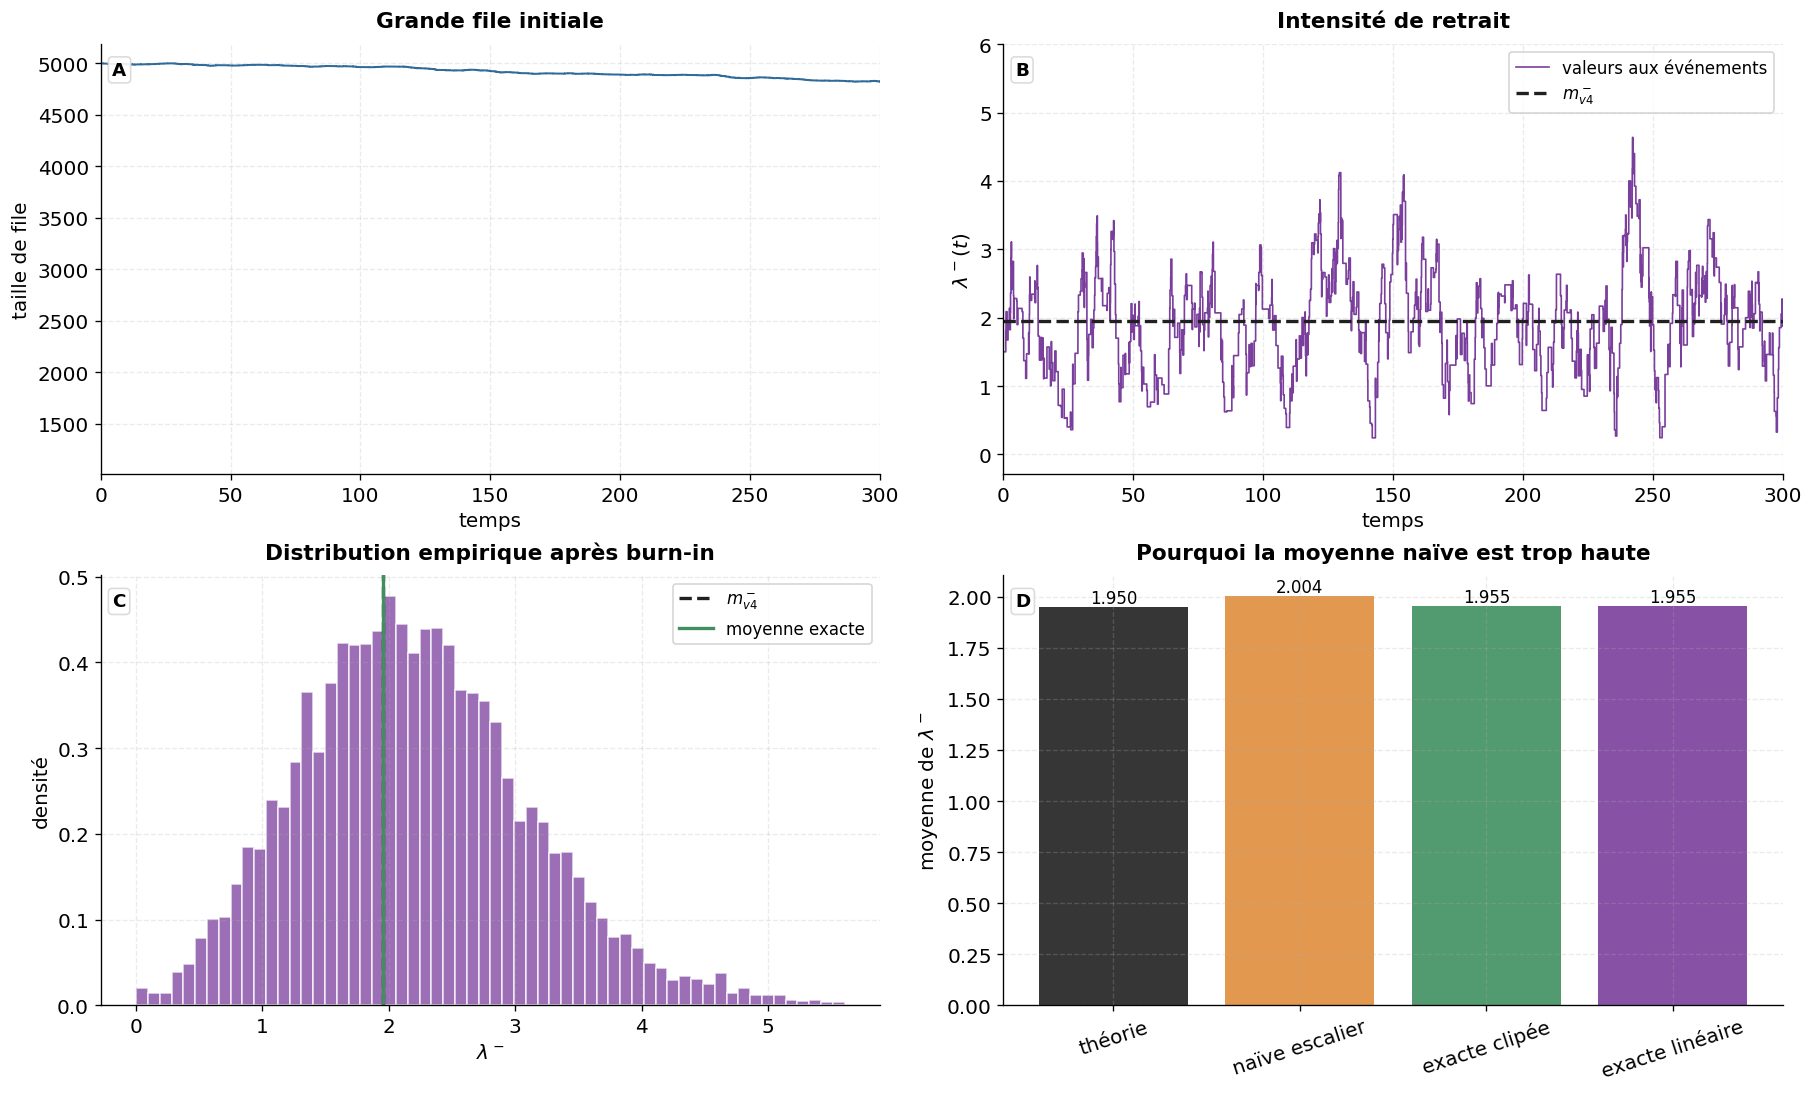

In [5]:
rng = np.random.default_rng(SEED)
T_long = 5_000.0
Q_STATIONNAIRE = 5_000

res_single = simulate_hawkes_queue(
    q_init=Q_STATIONNAIRE,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=T_long,
    rng=rng,
    stop_at_zero=True,
    sign_convention='v4',
)

burn = T_long / 2
lambda_naive = moyenne_escalier_naive(res_single.times, res_single.lambda_minus_path, T_long, burn)
lambda_exacte = moyenne_temporelle_exacte(res_single, T_long, burn, clipped=True)
lambda_lineaire = moyenne_temporelle_exacte(res_single, T_long, burn, clipped=False)

print(f"hit_zero = {res_single.hit_zero}, min(Q) = {res_single.queue_path.min():.0f}")
print(f"m⁻ théorique v4                 : {m_theo:.4f}")
print(f"moyenne naïve en escalier        : {lambda_naive:.4f}")
print(f"moyenne exacte avec troncature   : {lambda_exacte:.4f}")
print(f"moyenne exacte linéaire          : {lambda_lineaire:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

removals = np.cumsum(res_single.event_types == -1)
axes[0, 0].step(res_single.times, res_single.queue_path, where='post', color=COLORS['poisson'], linewidth=1.2)
axes[0, 0].set_xlim(0, 300)
style_axes(axes[0, 0], 'temps', 'taille de file', 'Grande file initiale')
add_panel_label(axes[0, 0], 'A')

axes[0, 1].step(res_single.times, res_single.lambda_minus_path, where='post', color=COLORS['hawkes'], linewidth=1.0, label='valeurs aux événements')
axes[0, 1].axhline(m_theo, color=COLORS['theory'], linestyle='--', linewidth=2.0, label=r'$m^-_{v4}$')
axes[0, 1].set_xlim(0, 300)
style_axes(axes[0, 1], 'temps', r'$\lambda^-(t)$', 'Intensité de retrait')
axes[0, 1].legend(frameon=True)
add_panel_label(axes[0, 1], 'B')

mask = res_single.times > burn
axes[1, 0].hist(res_single.lambda_minus_path[mask], bins=60, density=True, color=COLORS['hawkes'], alpha=0.75, edgecolor='white')
axes[1, 0].axvline(m_theo, color=COLORS['theory'], linestyle='--', linewidth=2.0, label=r'$m^-_{v4}$')
axes[1, 0].axvline(lambda_exacte, color=COLORS['green'], linewidth=2.0, label='moyenne exacte')
style_axes(axes[1, 0], r'$\lambda^-$', 'densité', 'Distribution empirique après burn-in')
axes[1, 0].legend(frameon=True)
add_panel_label(axes[1, 0], 'C')

comparaison = pd.Series({
    'théorie': m_theo,
    'naïve escalier': lambda_naive,
    'exacte clipée': lambda_exacte,
    'exacte linéaire': lambda_lineaire,
})
axes[1, 1].bar(comparaison.index, comparaison.values, color=[COLORS['theory'], COLORS['poisson2'], COLORS['green'], COLORS['hawkes']], alpha=0.9)
axes[1, 1].tick_params(axis='x', rotation=18)
style_axes(axes[1, 1], None, r'moyenne de $\lambda^-$', 'Pourquoi la moyenne naïve est trop haute')
for i, v in enumerate(comparaison.values):
    axes[1, 1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
add_panel_label(axes[1, 1], 'D')

plt.show()


**Interprétation.** La moyenne naïve en escalier peut être proche de $2.00$, alors que la moyenne exacte de l'intensité exponentiellement décroissante revient autour de $1.95$. La différence ne vient donc pas de la définition de $m^-$, mais de la méthode d'intégration empirique de $\lambda^-(t)$.


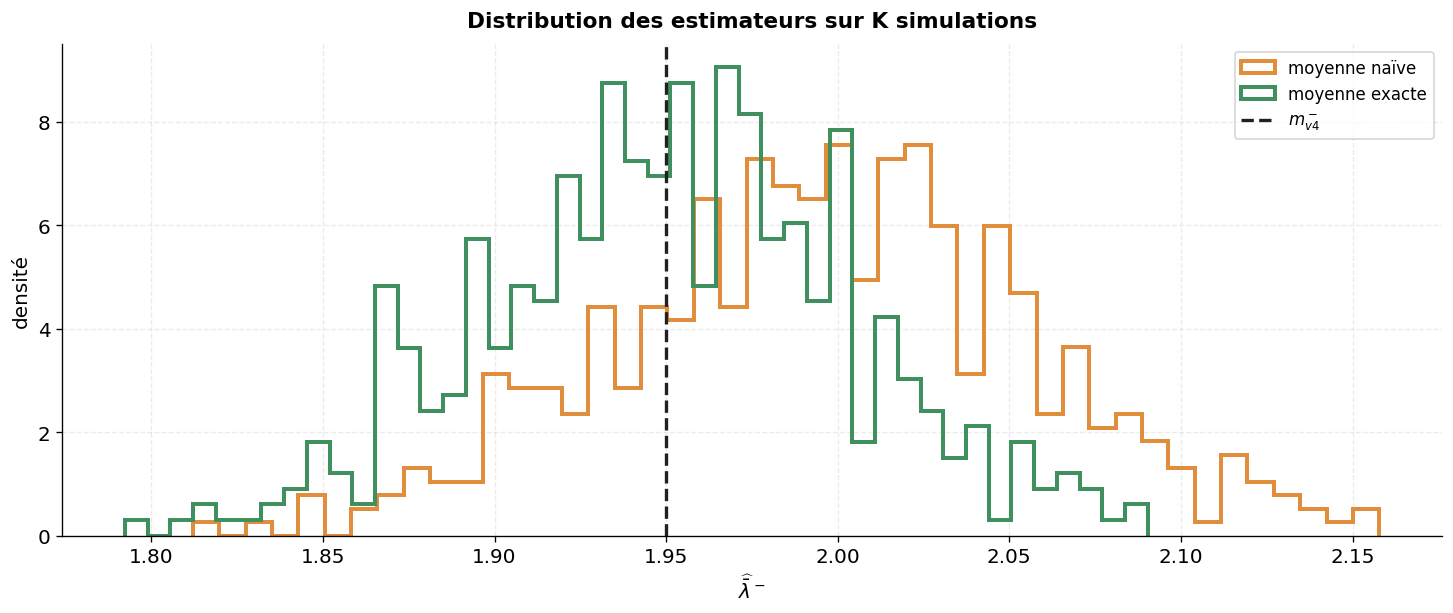

,estimateur,moyenne,std,IC 95% bas,IC 95% haut,référence m^-
0,naïf en escalier,1.995950,0.060344,1.990661,2.001240,1.95
1,exact exponentiel,1.950551,0.053230,1.945886,1.955217,1.95


In [6]:
K = 500
rng = np.random.default_rng(SEED)
lambda_naives = np.empty(K)
lambda_exactes = np.empty(K)

for k in range(K):
    r = simulate_hawkes_queue(
        q_init=Q_STATIONNAIRE,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=T_long,
        rng=rng,
        stop_at_zero=True,
        sign_convention='v4',
    )
    lambda_naives[k] = moyenne_escalier_naive(r.times, r.lambda_minus_path, T_long, burn)
    lambda_exactes[k] = moyenne_temporelle_exacte(r, T_long, burn, clipped=True)

m_naive, s_naive, lo_naive, hi_naive = ci95(lambda_naives)
m_exact, s_exact, lo_exact, hi_exact = ci95(lambda_exactes)

fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
ax.hist(lambda_naives, bins=45, density=True, histtype='step', linewidth=2.4, color=COLORS['poisson2'], label='moyenne naïve')
ax.hist(lambda_exactes, bins=45, density=True, histtype='step', linewidth=2.4, color=COLORS['green'], label='moyenne exacte')
ax.axvline(m_theo, color=COLORS['theory'], linestyle='--', linewidth=2.0, label=r'$m^-_{v4}$')
style_axes(ax, r'$\widehat{\bar\lambda}^-$', 'densité', 'Distribution des estimateurs sur K simulations')
ax.legend(frameon=True)
plt.show()

pd.DataFrame({
    'estimateur': ['naïf en escalier', 'exact exponentiel'],
    'moyenne': [m_naive, m_exact],
    'std': [s_naive, s_exact],
    'IC 95% bas': [lo_naive, lo_exact],
    'IC 95% haut': [hi_naive, hi_exact],
    'référence m^-': [m_theo, m_theo],
})


## B.5 Question 1.2.4.2 — Temps d'atteinte d'une file Hawkes

On simule maintenant des temps d'atteinte avec $Q(0)=10$. Ici, la frontière $Q=0$ est précisément l'objet étudié : toutes les simulations Hawkes utilisent `stop_at_zero=True`.


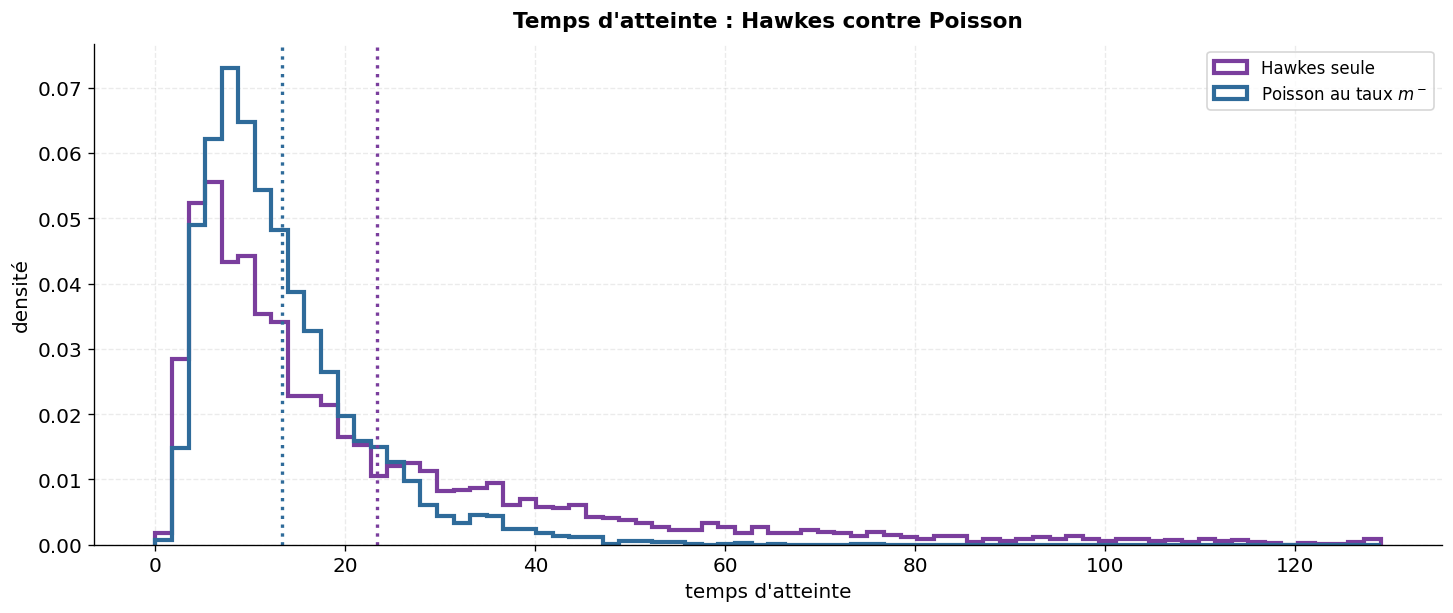

,modèle,moyenne,écart-type,n
0,Hawkes seule,23.303684,27.136889,5000
1,Poisson au taux m^-,13.349698,8.545489,5000


In [7]:
def simuler_temps_poisson_une_file(n_runs, q_init, lambda_plus, lambda_minus, rng, t_max=2_000.0):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        q = q_init
        t = 0.0
        total = lambda_plus + lambda_minus
        while q > 0 and t < t_max:
            t += rng.exponential(1.0 / total)
            q += 1 if rng.random() < lambda_plus / total else -1
        temps[k] = t
    return temps


N_hit = 5_000
rng = np.random.default_rng(SEED)
temps_hawkes_simple = np.empty(N_hit)
for k in range(N_hit):
    r = simulate_hawkes_queue(
        q_init=Q0,
        mu_plus=MU_PLUS,
        mu_minus=MU_MINUS,
        alpha=ALPHA,
        beta=BETA,
        T_max=2_000.0,
        rng=rng,
        stop_at_zero=True,
        sign_convention='v4',
    )
    temps_hawkes_simple[k] = r.hitting_time

temps_poisson_eff = simuler_temps_poisson_une_file(N_hit, Q0, MU_PLUS, m_theo, rng)

bins = np.linspace(0, np.quantile(np.r_[temps_hawkes_simple, temps_poisson_eff], 0.995), 75)
fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
ax.hist(temps_hawkes_simple, bins=bins, density=True, histtype='step', linewidth=2.5, color=COLORS['hawkes'], label='Hawkes seule')
ax.hist(temps_poisson_eff, bins=bins, density=True, histtype='step', linewidth=2.5, color=COLORS['poisson'], label='Poisson au taux $m^-$')
ax.axvline(temps_hawkes_simple.mean(), color=COLORS['hawkes'], linestyle=':', linewidth=2)
ax.axvline(temps_poisson_eff.mean(), color=COLORS['poisson'], linestyle=':', linewidth=2)
style_axes(ax, "temps d'atteinte", 'densité', "Temps d'atteinte : Hawkes contre Poisson")
ax.legend(frameon=True)
plt.show()

pd.DataFrame({
    'modèle': ['Hawkes seule', 'Poisson au taux m^-'],
    'moyenne': [temps_hawkes_simple.mean(), temps_poisson_eff.mean()],
    'écart-type': [temps_hawkes_simple.std(ddof=1), temps_poisson_eff.std(ddof=1)],
    'n': [len(temps_hawkes_simple), len(temps_poisson_eff)],
})


## B.6 Question 1.2.4.3 — Deux files Hawkes couplées

On couple les deux premières limites $Q_1$ et $Q_{-1}$. La convention v4 transmet les vagues de retraits entre les deux côtés : les retraits augmentent les intensités futures de retrait.


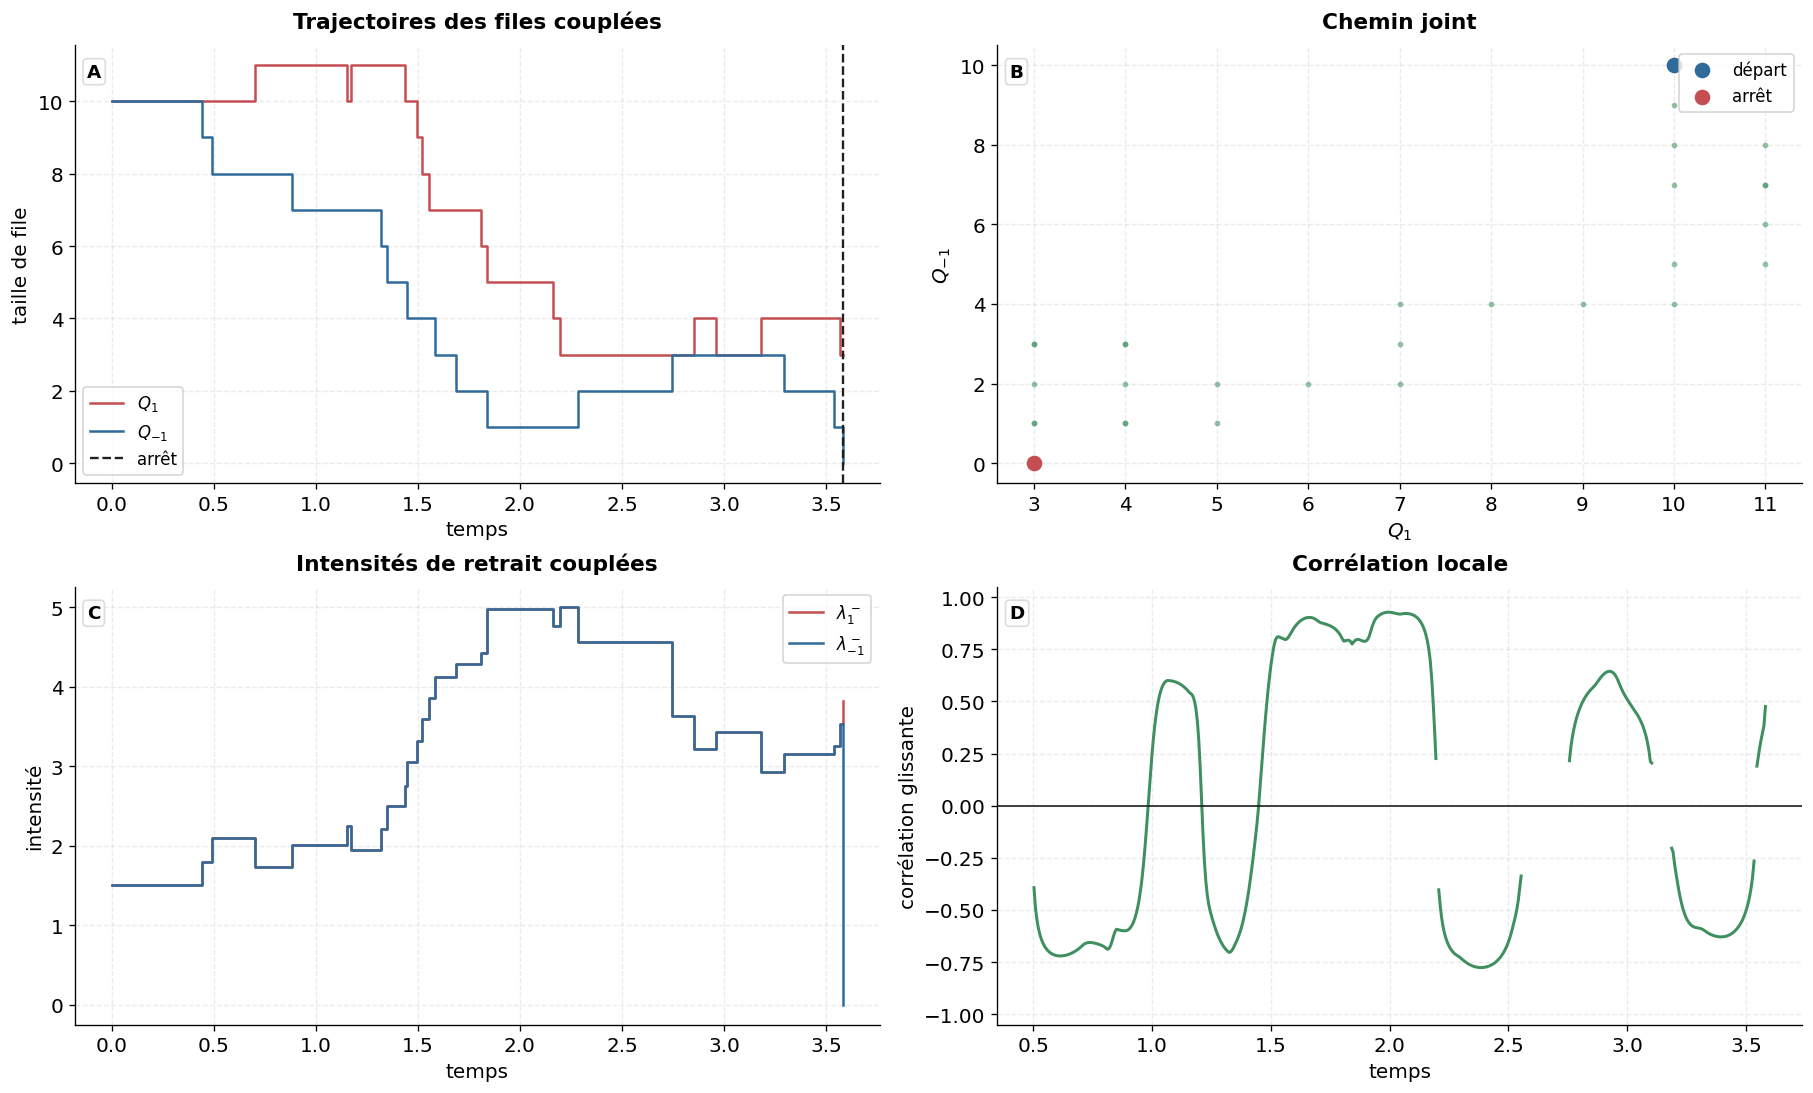

Temps d'arrêt : 3.5823
File touchée : Q₋₁
Corrélation globale interpolée : 0.863


In [8]:
rng = np.random.default_rng(SEED)
res_c = simulate_coupled_hawkes(
    q1_init=Q0,
    q_neg1_init=Q0,
    mu_plus=MU_PLUS,
    mu_minus=MU_MINUS,
    alpha=ALPHA,
    beta=BETA,
    T_max=300.0,
    rng=rng,
    stop_at_zero=True,
    sign_convention='v4',
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

axes[0, 0].step(res_c.times, res_c.q1_path, where='post', color=COLORS['hawkes2'], label=r'$Q_1$')
axes[0, 0].step(res_c.times, res_c.q_neg1_path, where='post', color=COLORS['poisson'], label=r'$Q_{-1}$')
axes[0, 0].axvline(res_c.hitting_time, color=COLORS['theory'], linestyle='--', linewidth=1.4, label='arrêt')
style_axes(axes[0, 0], 'temps', 'taille de file', 'Trajectoires des files couplées')
axes[0, 0].legend(frameon=True)
add_panel_label(axes[0, 0], 'A')

axes[0, 1].plot(res_c.q1_path, res_c.q_neg1_path, '.', color=COLORS['green'], alpha=0.45, markersize=5)
axes[0, 1].scatter(res_c.q1_path[0], res_c.q_neg1_path[0], color=COLORS['poisson'], s=70, label='départ', zorder=4)
axes[0, 1].scatter(res_c.q1_path[-1], res_c.q_neg1_path[-1], color=COLORS['hawkes2'], s=70, label='arrêt', zorder=4)
style_axes(axes[0, 1], r'$Q_1$', r'$Q_{-1}$', 'Chemin joint')
axes[0, 1].legend(frameon=True)
add_panel_label(axes[0, 1], 'B')

axes[1, 0].step(res_c.times, res_c.lam_minus_1_path, where='post', color=COLORS['hawkes2'], label=r'$\lambda^-_1$')
axes[1, 0].step(res_c.times, res_c.lam_minus_neg1_path, where='post', color=COLORS['poisson'], label=r'$\lambda^-_{-1}$')
style_axes(axes[1, 0], 'temps', 'intensité', 'Intensités de retrait couplées')
axes[1, 0].legend(frameon=True)
add_panel_label(axes[1, 0], 'C')

grid = np.linspace(res_c.times[0], res_c.times[-1], 600)
q1_i = np.interp(grid, res_c.times, res_c.q1_path)
qn_i = np.interp(grid, res_c.times, res_c.q_neg1_path)
window = min(60, max(5, len(grid) // 5))
corr = np.full(len(grid), np.nan)
for i in range(window, len(grid)):
    if np.std(q1_i[i-window:i]) > 0 and np.std(qn_i[i-window:i]) > 0:
        corr[i] = np.corrcoef(q1_i[i-window:i], qn_i[i-window:i])[0, 1]
axes[1, 1].plot(grid, corr, color=COLORS['green'], linewidth=1.8)
axes[1, 1].axhline(0, color=COLORS['theory'], linewidth=1)
axes[1, 1].set_ylim(-1.05, 1.05)
style_axes(axes[1, 1], 'temps', 'corrélation glissante', 'Corrélation locale')
add_panel_label(axes[1, 1], 'D')

plt.show()

print(f"Temps d'arrêt : {res_c.hitting_time:.4f}")
print(f"File touchée : {'Q₁' if res_c.which_hit == 1 else 'Q₋₁'}")
print(f"Corrélation globale interpolée : {np.corrcoef(q1_i, qn_i)[0, 1]:.3f}")


## B.7 Question 1.2.4.4 — Comparaison des temps d'atteinte

On compare quatre modèles : une file Poisson, deux files Poisson indépendantes, une file Hawkes et deux files Hawkes couplées.


In [9]:
def simuler_temps_poisson_min(n_runs, q_init, lambda_plus, lambda_minus, rng):
    temps = np.empty(n_runs)
    for k in range(n_runs):
        r = simulate_until_hit_zero(
            q1_init=q_init,
            q_neg1_init=q_init,
            lambda_plus=lambda_plus,
            lambda_minus=lambda_minus,
            rng=rng,
            record_path=False,
        )
        temps[k] = r.hitting_time
    return temps


def resume(arr):
    arr = np.asarray(arr)
    m = arr.mean()
    s = arr.std(ddof=1)
    h = 1.96 * s / np.sqrt(len(arr))
    return m, s, m - h, m + h, len(arr)


N_comp = 2_000
rng = np.random.default_rng(SEED)

single_poisson = simuler_temps_poisson_une_file(N_comp, Q0, MU_PLUS, MU_MINUS, rng)
two_poisson = simuler_temps_poisson_min(N_comp, Q0, MU_PLUS, MU_MINUS, rng)

single_hawkes = np.empty(N_comp)
for k in range(N_comp):
    r = simulate_hawkes_queue(Q0, MU_PLUS, MU_MINUS, ALPHA, BETA, 2_000.0, rng, True, 'v4')
    single_hawkes[k] = r.hitting_time

two_hawkes = np.empty(N_comp)
for k in range(N_comp):
    r = simulate_coupled_hawkes(Q0, Q0, MU_PLUS, MU_MINUS, ALPHA, BETA, 2_000.0, rng, True, 'v4')
    two_hawkes[k] = r.hitting_time

raw = {
    '2 Hawkes couplées': two_hawkes,
    '1 Hawkes': single_hawkes,
    'min 2 Poisson': two_poisson,
    '1 Poisson': single_poisson,
}

summary = []
for name, arr in raw.items():
    m, s, lo, hi, n = resume(arr)
    summary.append({'modèle': name, 'E[T]': m, 'std': s, 'IC 95% bas': lo, 'IC 95% haut': hi, 'n': n})
summary = pd.DataFrame(summary)
summary


,modèle,E[T],std,IC 95% bas,IC 95% haut,n
0,2 Hawkes couplées,14.679343,17.540529,13.910596,15.448091,2000
1,1 Hawkes,22.566062,25.205461,21.461384,23.670740,2000
2,min 2 Poisson,18.777855,13.357535,18.192436,19.363275,2000
3,1 Poisson,33.006574,31.118112,31.642763,34.370385,2000


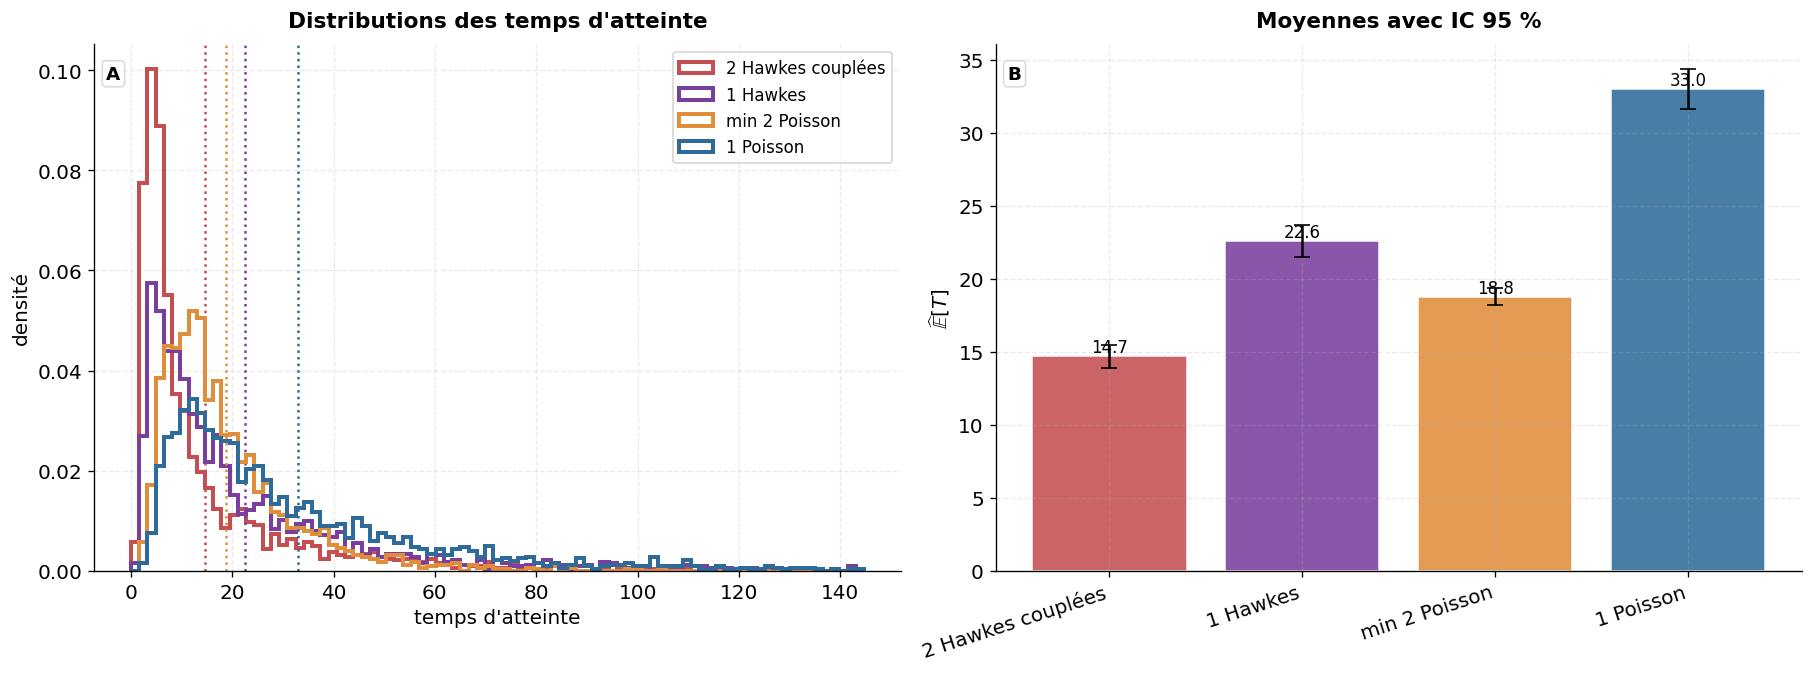

Ordre croissant observé :
  2 Hawkes couplées    : 14.6793
  min 2 Poisson        : 18.7779
  1 Hawkes             : 22.5661
  1 Poisson            : 33.0066


In [10]:
ordre = ['2 Hawkes couplées', '1 Hawkes', 'min 2 Poisson', '1 Poisson']
plot_colors = {
    '2 Hawkes couplées': COLORS['hawkes2'],
    '1 Hawkes': COLORS['hawkes'],
    'min 2 Poisson': COLORS['poisson2'],
    '1 Poisson': COLORS['poisson'],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), layout='constrained')
values = np.concatenate([raw[k] for k in ordre])
bins = np.linspace(0, np.quantile(values, 0.995), 90)

for name in ordre:
    axes[0].hist(raw[name], bins=bins, density=True, histtype='step', linewidth=2.4, color=plot_colors[name], label=name)
    axes[0].axvline(raw[name].mean(), color=plot_colors[name], linestyle=':', linewidth=1.5)
style_axes(axes[0], "temps d'atteinte", 'densité', 'Distributions des temps d\'atteinte')
axes[0].legend(frameon=True)
add_panel_label(axes[0], 'A')

table_ord = summary.set_index('modèle').loc[ordre]
means = table_ord['E[T]'].values
errs = np.vstack([means - table_ord['IC 95% bas'].values, table_ord['IC 95% haut'].values - means])
axes[1].bar(range(len(ordre)), means, yerr=errs, capsize=5, color=[plot_colors[k] for k in ordre], alpha=0.88, edgecolor='white')
axes[1].set_xticks(range(len(ordre)))
axes[1].set_xticklabels(ordre, rotation=18, ha='right')
for i, v in enumerate(means):
    axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)
style_axes(axes[1], None, r'$\widehat{\mathbb{E}}[T]$', 'Moyennes avec IC 95 %')
add_panel_label(axes[1], 'B')

plt.show()

print('Ordre croissant observé :')
for name in table_ord.sort_values('E[T]').index:
    print(f"  {name:20s} : {table_ord.loc[name, 'E[T]']:.4f}")


## B.8 Sensibilité à $\alpha/\beta$

En convention v4, la moyenne théorique sans bord est :

$$
m^-(r)=\frac{\mu^- - r\mu^+}{1-r},
\qquad r=\frac{\alpha}{\beta}.
$$

Quand $r$ approche $1$, la condition de stationnarité devient critique.


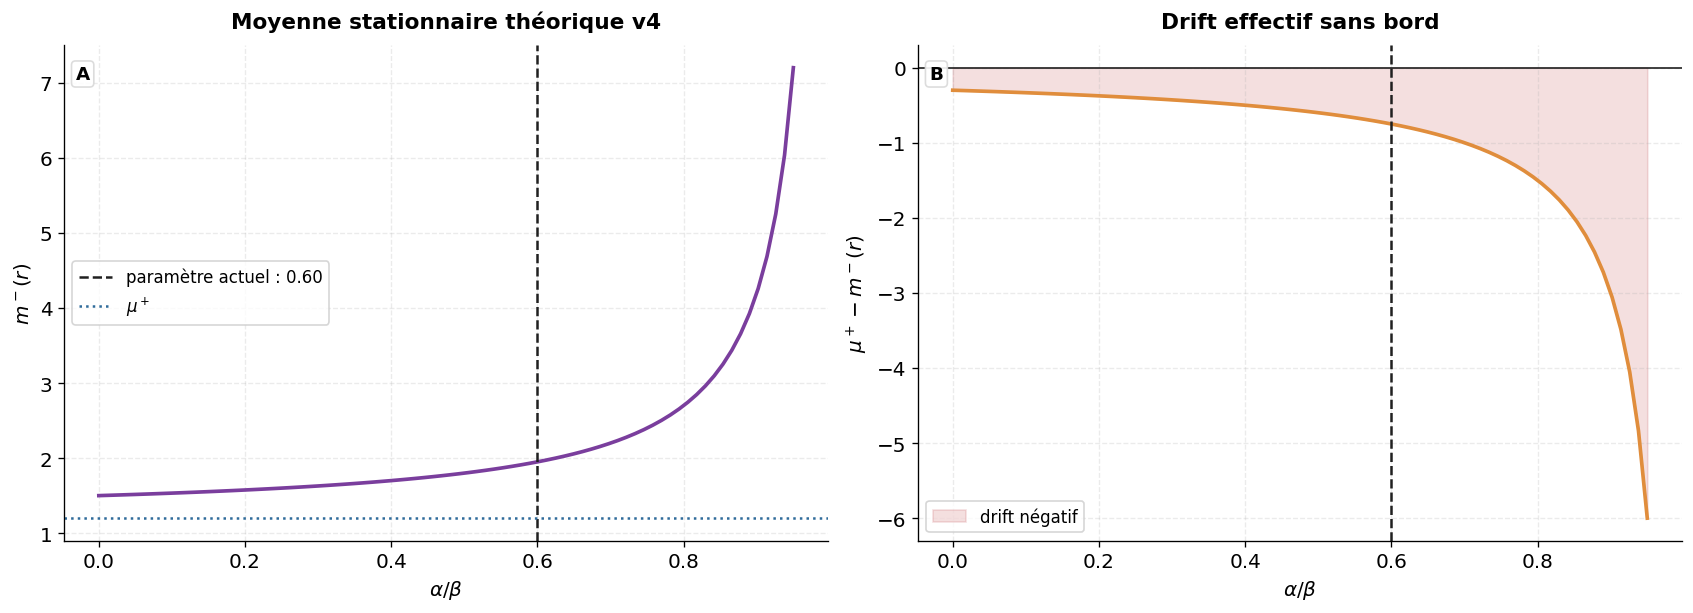

In [11]:
ratios = np.linspace(0, 0.95, 80)
m_values = (MU_MINUS - ratios * MU_PLUS) / (1 - ratios)
drift_values = MU_PLUS - m_values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')
axes[0].plot(ratios, m_values, color=COLORS['hawkes'], linewidth=2.2)
axes[0].axvline(RATIO, color=COLORS['theory'], linestyle='--', label=f'paramètre actuel : {RATIO:.2f}')
axes[0].axhline(MU_PLUS, color=COLORS['poisson'], linestyle=':', label=r'$\mu^+$')
style_axes(axes[0], r'$\alpha/\beta$', r'$m^-(r)$', 'Moyenne stationnaire théorique v4')
axes[0].legend(frameon=True)
add_panel_label(axes[0], 'A')

axes[1].plot(ratios, drift_values, color=COLORS['poisson2'], linewidth=2.2)
axes[1].axhline(0, color=COLORS['theory'], linewidth=1)
axes[1].axvline(RATIO, color=COLORS['theory'], linestyle='--')
axes[1].fill_between(ratios, drift_values, 0, where=drift_values < 0, color=COLORS['hawkes2'], alpha=0.18, label='drift négatif')
style_axes(axes[1], r'$\alpha/\beta$', r'$\mu^+ - m^-(r)$', 'Drift effectif sans bord')
axes[1].legend(frameon=True)
add_panel_label(axes[1], 'B')

plt.show()


---
## Résumé

| Point | Conclusion |
|---|---|
| Section 2.1 | Le discret et le brownien donnent tous deux une probabilité $1$ quand $\mu\leq 0$, mais des taux exponentiels différents quand $\mu>0$. |
| Hawkes v4 | Les ajouts diminuent temporairement $\lambda^-$, les retraits l'augmentent. |
| Moyenne de $\lambda^-$ | La moyenne correcte doit intégrer la décroissance exponentielle entre événements ; une moyenne en escalier surestime $\bar\lambda^-$. |
| Stationnarité | Pour $r=\alpha/\beta<1$, $m^-=(\mu^- - r\mu^+)/(1-r)$. |
| Temps d'atteinte | Le couplage Hawkes modifie fortement la forme et la moyenne des temps d'atteinte. |
